# UdaciSense: Optimized Object Recognition

## Notebook 3: Multi-step Optimization Pipeline

 
In this notebook, you'll implement the multi-step optimization pipeline based on the findings from the previous experiments. The goal is to combine different optimization techniques to meet all requirements:

- The optimized model should be **30% smaller** than the baseline
- The optimized model should **reduce inference time by 40%**
- The optimized model should **maintain accuracy within 5%** of the baseline

You may need to experiment with different pipelines as you try to hit your targets. Make sure to start with those that are easier to implement!

### Overview: Implementation Plan

**TODO**: *Add your implementation plan here*

### Step 1: Set up the environment

In [1]:
# Make sure that libraries are dynamically re-loaded if changed
get_ipython().run_line_magic('load_ext', 'autoreload')
get_ipython().run_line_magic('autoreload', '2')

In [2]:
# Import necessary libraries
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pprint
import random
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from compression.post_training.pruning import prune_model
from compression.post_training.quantization import quantize_model
from compression.post_training.graph_optimization import optimize_model, verify_model_equivalence
from compression.in_training.distillation import train_with_distillation, MobileNetV3_Household_Small
from compression.in_training.pruning import train_with_pruning
from compression.in_training.quantization import train_model_qat, QuantizableMobileNetV3_Household

from utils import MAX_ALLOWED_ACCURACY_DROP, TARGET_INFERENCE_SPEEDUP, TARGET_MODEL_COMPRESSION
from utils.data_loader import get_household_loaders, get_input_size, print_dataloader_stats, visualize_batch
from utils.model import MobileNetV3_Household, load_model, save_model, print_model_summary
from utils.visualization import plot_multiple_models_comparison
from utils.compression import (
    compare_experiments, compare_optimized_model_to_baseline, evaluate_optimized_model, list_experiments,  # For experimentation
    is_quantized  # For quantization
)

In [3]:
# Ignore PyTorch deprecation warnings
import warnings
warnings.filterwarnings("ignore", category=torch.jit.TracerWarning)
warnings.filterwarnings("ignore", category=UserWarning)  # Optional: Ignore all user warnings

In [4]:
# Check if CUDA is available
devices = ["cpu"]
if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    devices.extend([f"cuda:{i} ({torch.cuda.get_device_name(i)})" for i in range(num_devices)])
print(f"Devices available: {devices}")

Devices available: ['cpu', 'cuda:0 (Tesla T4)']


In [5]:
# Set random seed for reproducibility
def set_deterministic_mode(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    return seed_worker

set_deterministic_mode(42)
g = torch.Generator()
g.manual_seed(42)

### Step 2: Load the dataset

Extracting household classes from CIFAR100 for train set...
Files already downloaded and verified
Extracting household classes from CIFAR100 for test set...
Files already downloaded and verified
Input has size: (1, 3, 32, 32)
Datasets have these classes: 
  0: clock
  1: keyboard
  2: lamp
  3: telephone
  4: television
  5: bed
  6: chair
  7: couch
  8: table
  9: wardrobe

Information on train set
Statistics for train
 Size: 5000
 Samples per class:
  clock: 500
  keyboard: 500
  lamp: 500
  telephone: 500
  television: 500
  bed: 500
  chair: 500
  couch: 500
  table: 500
  wardrobe: 500
Examples of images from the train set


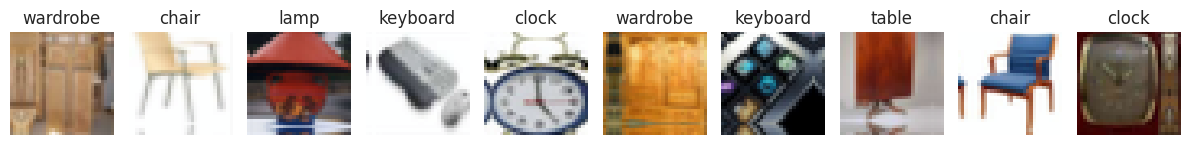


Information on test set
Statistics for test
 Size: 1000
 Samples per class:
  clock: 100
  keyboard: 100
  lamp: 100
  telephone: 100
  television: 100
  bed: 100
  chair: 100
  couch: 100
  table: 100
  wardrobe: 100
Examples of images from the test set


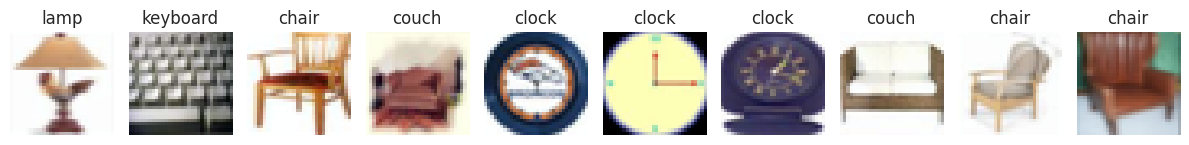

In [6]:
# Load household objects dataset
train_loader, test_loader = get_household_loaders(
    image_size="CIFAR", batch_size=128, num_workers=2,
)

# Get input_size
input_size = get_input_size("CIFAR")
print(f"Input has size: {input_size}")

# Get class names
class_names = train_loader.dataset.classes
print(f"Datasets have these classes: ")
for i in range(len(class_names)):
    print(f"  {i}: {class_names[i]}")

# Visualize some examples
for dataset_type, data_loader in [('train', train_loader), ('test', test_loader)]:
    print(f"\nInformation on {dataset_type} set")
    print_dataloader_stats(data_loader, dataset_type)
    print(f"Examples of images from the {dataset_type} set")
    visualize_batch(data_loader, num_images=10)

### Step 3: Load the baseline model and metrics

In [7]:
# Load the baseline model
baseline_model = MobileNetV3_Household()
baseline_model_name = "baseline_mobilenet"
baseline_model.load_state_dict(torch.load(f"../models/{baseline_model_name}/checkpoints/model.pth"))
print_model_summary(baseline_model)

# Load baseline metrics
with open(f"../results/{baseline_model_name}/metrics.json", "r") as f:
    baseline_metrics = json.load(f)

print("\nBaseline Model Metrics:")
pprint.pp(baseline_metrics)

# Calculate target metrics based on CTO requirements
target_model_size = baseline_metrics['size']['model_size_mb'] * (1 - TARGET_MODEL_COMPRESSION)
target_inference_time_cpu = baseline_metrics['timing']['cpu']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
if torch.cuda.is_available():
    target_inference_time_gpu = baseline_metrics['timing']['cuda']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
min_acceptable_accuracy = baseline_metrics['accuracy']['top1_acc'] * (1 - MAX_ALLOWED_ACCURACY_DROP) 

print("Optimization Targets:")
print(f"Target Model Size: {baseline_metrics['size']['model_size_mb']:.2f} --> {target_model_size:.2f} MB ({TARGET_MODEL_COMPRESSION*100}% reduction)")
print(f"Target Inference Time (CPU): {baseline_metrics['timing']['cpu']['avg_time_ms']:.2f} --> {target_inference_time_cpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
if torch.cuda.is_available():
    print(f"Target Inference Time (GPU): {baseline_metrics['timing']['cuda']['avg_time_ms']:.2f} --> {target_inference_time_gpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
print(f"Minimum Acceptable Accuracy: {baseline_metrics['accuracy']['top1_acc']:.2f} --> {min_acceptable_accuracy:.2f} (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /home/student/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:00<00:00, 95.6MB/s]
/tmp/ipykernel_9375/3650396802.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't 

Model Architecture:
MobileNetV3_Household(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
   

### Step 4: Implement and evaluate optimization pipelines

Based on your analysis in the previous notebook, you'll implement and evaluate different multi-step pipelines to find the optimal approach for meeting all requirements.

In [8]:
# NOTE: Feel free to change the class entirely, or to move to a function if preferred
class OptimizationPipeline:
    def __init__(self, name, baseline_model, train_loader, test_loader, class_names, input_size):
        """
        Initialize the optimization pipeline.
        
        Args:
            name: Name of the pipeline for tracking and saving
            baseline_model: The baseline model to optimize
            train_loader: DataLoader for training data (needed for some optimization techniques)
            test_loader: DataLoader for testing data (needed for evaluation)
            class_names: List of class names in the dataset
            input_size: Input tensor size
        """
        self.name = name
        self.baseline_model = baseline_model
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.class_names = class_names
        self.input_size = input_size
        self.optimized_model = None
        self.steps = []
        self.results = {}
        
        # Create directories for this pipeline
        self.model_dir = f"../models/pipeline/{name}"
        self.checkpoint_dir = f"{self.model_dir}/checkpoints"
        self.results_dir = f"../results/pipeline/{name}"
        
        for d in [self.model_dir, self.checkpoint_dir, self.results_dir]:
            os.makedirs(d, exist_ok=True)
    
    def add_step(self, step_name, step_function, **kwargs):
        """
        Add an optimization step to the pipeline.
        
        Args:
            step_name: Name of the step
            step_function: Function that implements the step
            **kwargs: Arguments to pass to the step function
        """
        self.steps.append({
            'name': step_name,
            'function': step_function,
            'args': kwargs
        })
        return self
    
    def run(self, device=torch.device('cpu'), file_extension='pth'):
        """
        Run the optimization pipeline.
        
        Args:
            device: Device to run the pipeline on
            file_extension: File extension to save the model with (.pt for torchscript, else .pth)
            
        Returns:
            The optimized model
        """
        print(f"\n{'='*50}")
        print(f"Running pipeline: {self.name}")
        print(f"{'='*50}\n")
        
        # Start with the baseline model
        current_model = self.baseline_model
        
        # Save intermediate results after each step
        step_results = []
        
        # TODO: Run the pipeline iteratively
        # For each stage in the pipeline:
        # 1. Apply the specified technique with the given parameters
        # 2. Evaluate the model after applying the technique
        # 3. Store the results for later comparison
        for i, step in enumerate(self.steps):
            print(f"\n{'-'*50}")
            print(f"Step {i+1}: {step['name']}")
            print(f"{'-'*50}\n")
            
            # ...Add your code here...
            current_model = step['function'](current_model, **step['args'])
            
            step_experiment_name = f"pipeline/{self.name}/step{i+1}_{step['name']}"
            step_metrics, _ = evaluate_optimized_model(
                current_model, self.test_loader, step_experiment_name,
                self.class_names, self.input_size, device=device,
            )
            
            step_results.append({'step_name': step['name'], 'metrics': step_metrics})
        
        self.optimized_model = current_model
        final_path = f"{self.model_dir}/model.{file_extension}"
        
        # TODO: Save final model
        # Remember that different pytorch model format will require different saving mechanisms
        torch.jit.save(current_model, final_path)
        
        final_metrics, _ = evaluate_optimized_model(
            current_model, self.test_loader, f"pipeline/{self.name}",
            self.class_names, self.input_size, device=device,
        )
        final_comparison = compare_optimized_model_to_baseline(
            self.baseline_model, current_model, f"pipeline/{self.name}",
            self.test_loader, self.class_names, device=device,
        )
        
        # Save pipeline results
        self.results = {
            'pipeline_name': self.name,
            'steps': step_results,
            'final_metrics': final_metrics,  # As returned by evaluate_optimized_model()
            'final_comparison': final_comparison  # As returned by compare_optimized_model_to_baseline()
        }
        
        with open(f"{self.results_dir}/pipeline_metrics.json", 'w') as f:
            json.dump(self.results, f, indent=4)
        
        print(f"\n{'='*50}")
        print(f"Pipeline {self.name} completed")
        print(f"{'='*50}\n")
        
        return self.optimized_model
    
    def visualize_results(self, baseline_metrics=baseline_metrics, device=torch.device('cpu')):
        """
        Visualize the results of the pipeline.

        Args:
            baseline_metrics: Dictionary of baseline metrics for comparison.
            device: Device to run the pipeline on

        """
        if not self.results:
            print("No results to visualize. Please run the pipeline first.")
            return

        # Define device name
        device_name = 'cpu' if device==torch.device('cpu') else 'cuda'

        # Extract metrics from each step
        step_names = [step['step_name'] for step in self.results['steps']]
        model_sizes = [step['metrics']['size']['model_size_mb'] for step in self.results['steps']]
        model_memory_sizes = [step['metrics']['size']['total_params'] for step in self.results['steps']]
        times = [step['metrics']['timing'][device_name]['avg_time_ms'] for step in self.results['steps']]
        accuracies = [step['metrics']['accuracy']['top1_acc'] for step in self.results['steps']]

        # Add baseline metrics
        step_names.insert(0, 'Baseline')
        baseline_size = baseline_metrics['size']['model_size_mb']
        baseline_memory_size = baseline_metrics['size']['total_params']
        baseline_inference_time = baseline_metrics['timing'][device_name]['avg_time_ms']
        baseline_accuracy = baseline_metrics['accuracy']['top1_acc']

        model_sizes.insert(0, baseline_size)
        model_memory_sizes.insert(0, baseline_memory_size)
        times.insert(0, baseline_inference_time)
        accuracies.insert(0, baseline_accuracy)

        # Create figure with subplots
        fig, axes = plt.subplots(4, 1, figsize=(12, 15))

        # Plot model size
        axes[0].bar(step_names, model_sizes, color='blue')
        axes[0].set_title('Model Size (MB)')
        axes[0].set_ylabel('Size (MB)')
        axes[0].axhline(y=baseline_size * (1-TARGET_MODEL_COMPRESSION), color='r', linestyle='--', label=f"Target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        axes[0].legend()
        for i, v in enumerate(model_sizes):
            axes[0].text(i, v + 0.1, f"{v:.2f}", ha='center')

        axes[1].bar(step_names, model_memory_sizes, color='blue')
        axes[1].set_title('Model Size (# Parameters)')
        axes[1].set_ylabel('Peak Memory')
        axes[1].axhline(y=baseline_memory_size * (1-TARGET_MODEL_COMPRESSION), color='r', linestyle='--', label=f"Target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        axes[1].legend()
        for i, v in enumerate(model_memory_sizes):
            axes[1].text(i, v + 0.1, f"{v:.2f}", ha='center')

        # Plot inference time
        axes[2].bar(step_names, times, color='green')
        axes[2].set_title('Inference Time (ms)')
        axes[2].set_ylabel('Time (ms)')
        axes[2].axhline(y=baseline_inference_time * (1-TARGET_INFERENCE_SPEEDUP), color='r', linestyle='--', label=f"Target ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
        axes[2].legend()
        for i, v in enumerate(times):
            axes[2].text(i, v + 0.1, f"{v:.2f}", ha='center')

        # Plot accuracy
        axes[3].bar(step_names, accuracies, color='purple')
        axes[3].set_title('Top-1 Accuracy (%)')
        axes[3].set_ylabel('Accuracy (%)')
        axes[3].axhline(y=baseline_accuracy * (1-MAX_ALLOWED_ACCURACY_DROP), color='r', linestyle='--', label=f"Minimum acceptable ({MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")
        axes[3].legend()
        for i, v in enumerate(accuracies):
            axes[3].text(i, v + 0.5, f"{v:.2f}%", ha='center')

        plt.tight_layout()
        plt.savefig(f"{self.results_dir}/pipeline_visualization.png")
        plt.show()

        # Print final results summary
        print(f"\n{'='*50}")
        print(f"Pipeline {self.name} Results Summary")
        print(f"{'='*50}")

        # Size comparison
        size_reduction = (baseline_size - model_sizes[-1]) / baseline_size * 100
        print(f"\nModel Size (MB):")
        print(f"  Baseline: {baseline_size:.2f} MB")
        print(f"  Final: {model_sizes[-1]:.2f} MB")
        print(f"  Reduction: {size_reduction:.2f}%")
        target_size = baseline_size * (1-TARGET_MODEL_COMPRESSION)
        if model_sizes[-1] <= target_size:
            print(f"  ✅ Meets target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        else:
            print(f"  ❌ Does not meet target (Goal: {target_size:.2f} MB)")

        memory_size_reduction = (baseline_memory_size - model_memory_sizes[-1]) / baseline_memory_size * 100
        print(f"\nModel Size (# Parameters):")
        print(f"  Baseline: {baseline_memory_size:.2f} MB")
        print(f"  Final: {model_memory_sizes[-1]:.2f} MB")
        print(f"  Reduction: {memory_size_reduction:.2f}%")
        target_memory_size = baseline_memory_size * (1-TARGET_MODEL_COMPRESSION)
        if model_memory_sizes[-1] <= target_memory_size:
            print(f"  ✅ Meets target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        else:
            print(f"  ❌ Does not meet target (Goal: {target_memory_size:.2f} MB)")


        # Inference time comparison
        time_reduction = (baseline_inference_time - times[-1]) / baseline_inference_time * 100
        print(f"\nInference Time (CPU):")
        print(f"  Baseline: {baseline_inference_time:.2f} ms")
        print(f"  Final: {times[-1]:.2f} ms")
        print(f"  Reduction: {time_reduction:.2f}%")
        target_time = baseline_inference_time * (1-TARGET_INFERENCE_SPEEDUP)
        if times[-1] <= target_time:
            print(f"  ✅ Meets target ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
        else:
            print(f"  ❌ Does not meet target (Goal: {target_time:.2f} ms)")

        # Accuracy comparison
        accuracy_change = (accuracies[-1] - baseline_accuracy) / baseline_accuracy * 100
        print(f"\nAccuracy:")
        print(f"  Baseline: {baseline_accuracy:.2f}%")
        print(f"  Final: {accuracies[-1]:.2f}%")
        print(f"  Change: {accuracy_change:.2f}%")
        min_acceptable = baseline_accuracy * (1-MAX_ALLOWED_ACCURACY_DROP)
        if accuracies[-1] >= min_acceptable:
            print(f"  ✅ Meets target (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")
        else:
            print(f"  ❌ Does not meet target (Goal: ≥{min_acceptable:.2f}%)")

        # Overall assessment
        print(f"\nOverall Assessment:")
        if model_sizes[-1] <= target_size and times[-1] <= target_time and accuracies[-1] >= min_acceptable:
            print(f"  ✅ Pipeline meets all requirements")
        else:
            print(f"  ❌ Pipeline does not meet all requirements")

In [9]:
# TODO: Create helper functions for each compression technique you want to experiment with as a pipeline step
# Remember to parametrize the functions appropriately
def apply_post_training_pruning():
    pass

def apply_dynamic_quantization():
    pass

def apply_graph_optimization(model, optimization_method="torchscript",
                             input_shape=(1, 3, 32, 32), device=torch.device("cpu")):
    return optimize_model(model, optimization_method=optimization_method,
                          input_shape=input_shape, device=device)

def apply_knowledge_distillation():
    pass

def apply_in_training_pruning():
    pass

def apply_in_training_quantization(model, train_loader, test_loader, config, checkpoint_path,
                                   backend="x86", num_classes=10):
    quantizable_model = QuantizableMobileNetV3_Household(
        num_classes=num_classes, pretrained=False, quantize=False
    )
    quantizable_model.load_state_dict(model.state_dict())
    quantized_model, _, _, _ = train_model_qat(
        quantizable_model, train_loader, test_loader, config, checkpoint_path, backend
    )

    return quantized_model

In [10]:
qat_num_epochs = 15
qat_optimizer = optim.SGD(baseline_model.parameters(), lr=0.0001, momentum=0.9, weight_decay=1e-4)

qat_config = {
    'qat_start_epoch': 0,
    'freeze_bn_epochs': 3,
    'disable_observer_epochs': 5,
    'num_epochs': qat_num_epochs,
    'criterion': nn.CrossEntropyLoss(),
    'optimizer': qat_optimizer,
    'scheduler': optim.lr_scheduler.CosineAnnealingLR(qat_optimizer, T_max=qat_num_epochs),
    'patience': 5,
    'device': torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    'grad_clip_norm': 1.0,
}

#### Pipelines

Note: You may want to recreate the cell below for new pipelines too, if needed.


Running pipeline: qat_torchscript


--------------------------------------------------
Step 1: in_training_quantization
--------------------------------------------------

Training with quantization-aware training for 15 epochs
QAT start epoch: 0, Finetune BN stats epochs: 3
QAT will be activated after epoch 0


Epoch 1/15 [Test]: 100%|██████████| 8/8 [00:24<00:00,  3.08s/it, loss=1.03, acc=74.8]


Epoch 1/15 - Train Loss: 0.1998, Train Acc: 93.44%, Test Loss: 1.0338, Test Acc: 74.80%, LR: 0.000099, Time: 41.08s
New best quantized model! Saving... (74.80%)
Model saved to ../models/pipeline/qat_torchscript/checkpoints/qat.pth


Epoch 2/15 [Test]: 100%|██████████| 8/8 [00:25<00:00,  3.23s/it, loss=0.767, acc=82.3]


Epoch 2/15 - Train Loss: 0.1610, Train Acc: 94.72%, Test Loss: 0.7668, Test Acc: 82.30%, LR: 0.000096, Time: 41.47s
New best quantized model! Saving... (82.30%)
Model saved to ../models/pipeline/qat_torchscript/checkpoints/qat.pth


...

Epoch 13/15 - Train Loss: 0.0873, Train Acc: 97.00%, Test Loss: 0.5784, Test Acc: 85.80%, LR: 0.000004, Time: 37.71s
Early stopping at epoch 13. No improvement for 5 epochs.
Training completed. Best accuracy: 87.00%
Best QAT model saved as '../models/pipeline/qat_torchscript/checkpoints/qat.pth' at epoch 8
Converting best QAT model to fully quantized model...

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:27<00:00,  3.48s/it]


Baseline metrics saved at ../results/pipeline/qat_torchscript/step1_in_training_quantization/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:27<00:00,  3.45s/it]


Confusion matrix saved to ../results/pipeline/qat_torchscript/step1_in_training_quantization/confusion_matrix.png


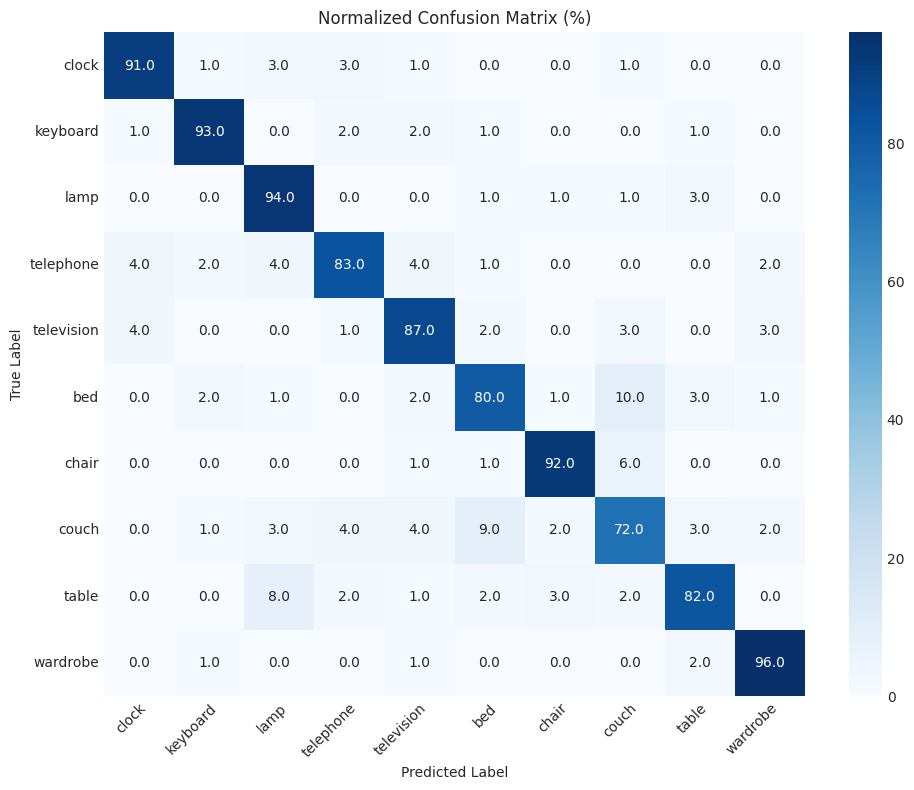


Optimized Model Metrics (pipeline/qat_torchscript/step1_in_training_quantization):
Accuracy: 86.30%
Model Size: 1.76 MB
CPU Inference Time: 127.00 ms (7.87 FPS)

--------------------------------------------------
Step 2: graph_optimization
--------------------------------------------------


Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:17<00:00,  2.19s/it]


Baseline metrics saved at ../results/pipeline/qat_torchscript/step2_graph_optimization/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:17<00:00,  2.19s/it]


Confusion matrix saved to ../results/pipeline/qat_torchscript/step2_graph_optimization/confusion_matrix.png


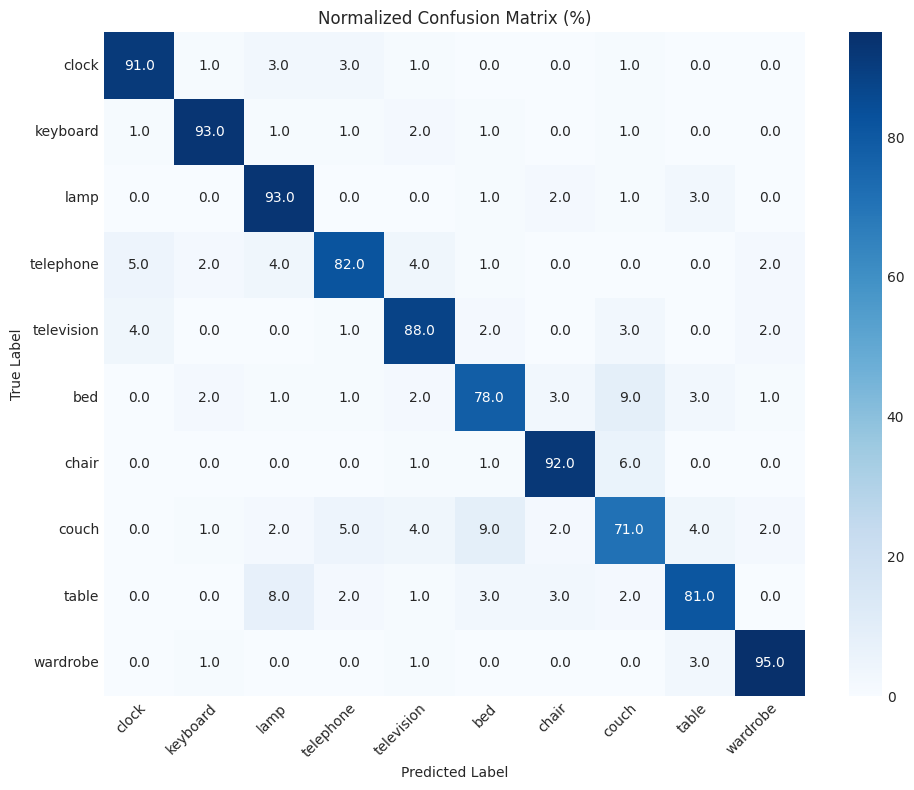


Optimized Model Metrics (pipeline/qat_torchscript/step2_graph_optimization):
Accuracy: 85.80%
Model Size: 1.70 MB
CPU Inference Time: 50.97 ms (19.62 FPS)

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:19<00:00,  2.46s/it]


Baseline metrics saved at ../results/pipeline/qat_torchscript/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:18<00:00,  2.35s/it]


Confusion matrix saved to ../results/pipeline/qat_torchscript/confusion_matrix.png


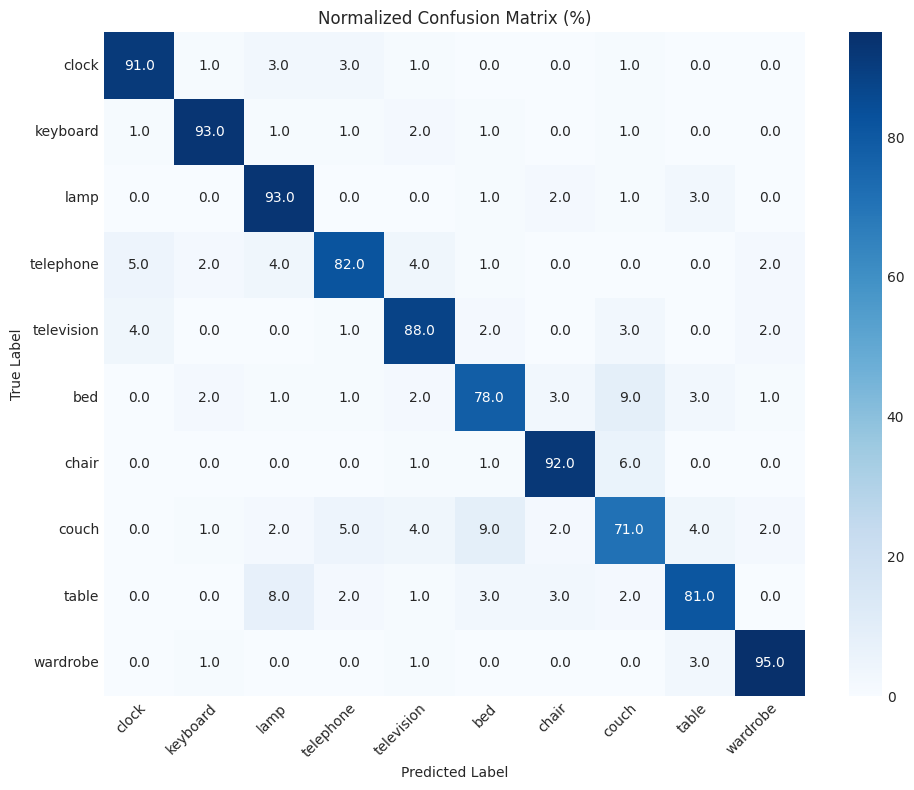


Optimized Model Metrics (pipeline/qat_torchscript):
Accuracy: 85.80%
Model Size: 1.70 MB
CPU Inference Time: 42.03 ms (23.79 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:35<00:00,  4.41s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:20<00:00,  2.60s/it]


Model comparison plot saved to ../results/pipeline/qat_torchscript/comparison.png


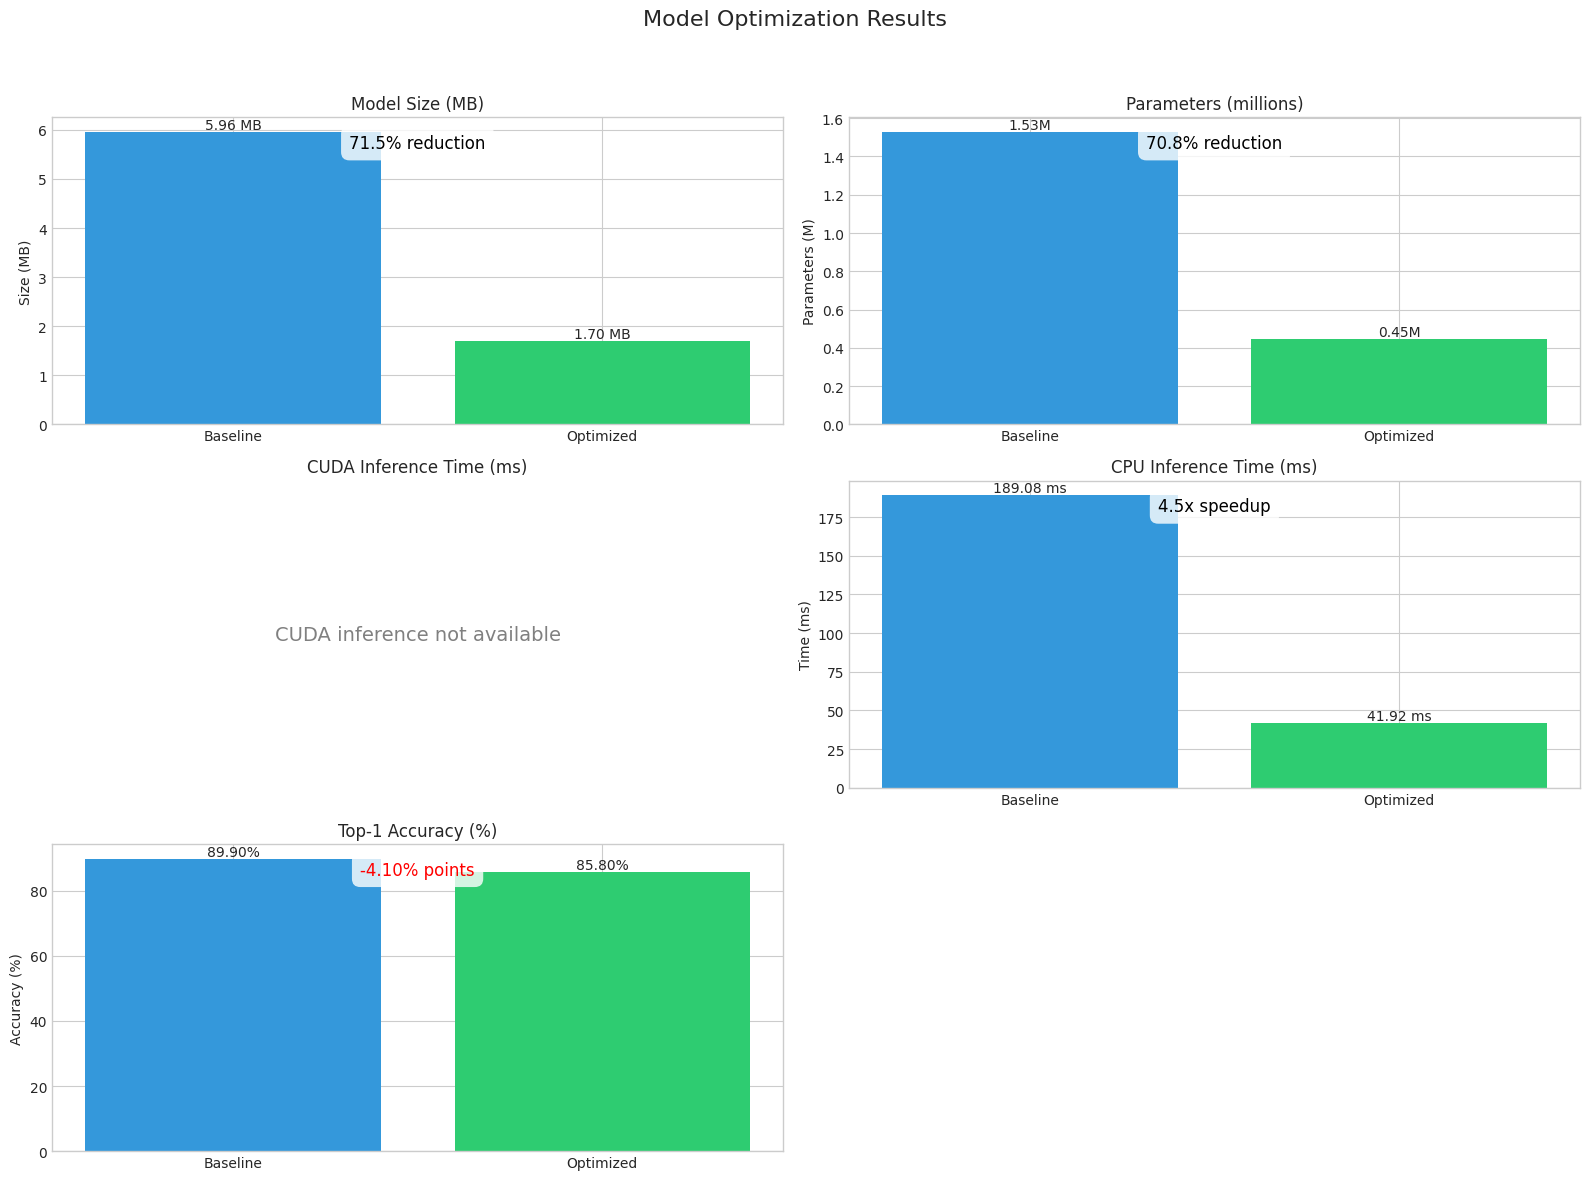


pipeline/qat_torchscript Results:
Model Size: 1.70 MB (71.5% reduction)
Parameters: 445,649 (70.8% reduction)
CPU Inference Time: 41.92 ms (4.5x speedup)
Accuracy: 85.80% (-4.10% change)
Requirements met: True

Pipeline qat_torchscript completed



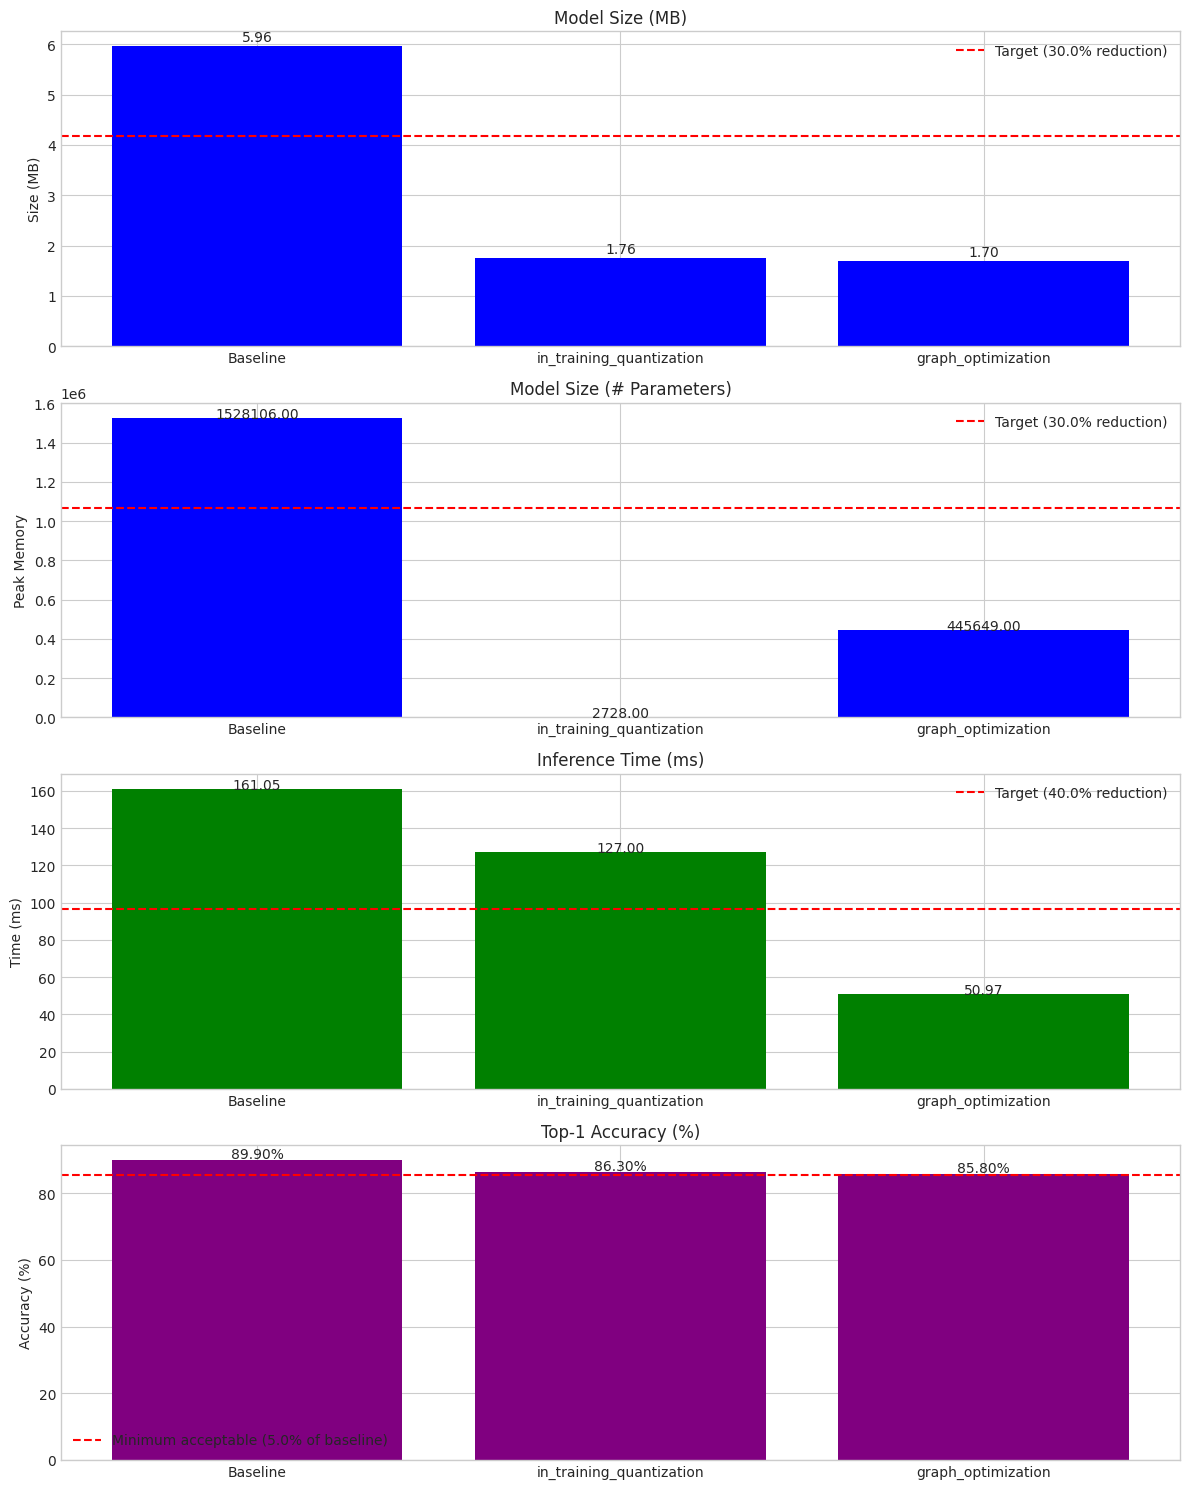


Pipeline qat_torchscript Results Summary

Model Size (MB):
  Baseline: 5.96 MB
  Final: 1.70 MB
  Reduction: 71.48%
  ✅ Meets target (30.0% reduction)

Model Size (# Parameters):
  Baseline: 1528106.00 MB
  Final: 445649.00 MB
  Reduction: 70.84%
  ✅ Meets target (30.0% reduction)

Inference Time (CPU):
  Baseline: 161.05 ms
  Final: 50.97 ms
  Reduction: 68.35%
  ✅ Meets target (40.0% reduction)

Accuracy:
  Baseline: 89.90%
  Final: 85.80%
  Change: -4.56%
  ✅ Meets target (within 5.0% of baseline)

Overall Assessment:
  ✅ Pipeline meets all requirements


In [11]:
# Create and run Pipeline #1

# TODO: Choose a meaningful and unique pipeline name 
pipeline_name = "qat_torchscript"

# Initialize the pipeline
pipeline1 = OptimizationPipeline(
    name=pipeline_name,
    baseline_model=baseline_model,
    train_loader=train_loader,
    test_loader=test_loader,
    class_names=class_names,
    input_size=input_size
)

# TODO: Add optimization steps using the add_step() function
pipeline1.add_step(
    "in_training_quantization",
    apply_in_training_quantization,
    train_loader=train_loader,
    test_loader=test_loader,
    config=qat_config,
    checkpoint_path=f"{pipeline1.checkpoint_dir}/qat.pth",
    backend="x86",
    num_classes=len(class_names),
)

pipeline1.add_step(
    "graph_optimization",
    apply_graph_optimization,
    optimization_method="torchscript",
    input_shape=input_size,
    device=torch.device("cpu"),
)

# Run the pipeline
optimized_model_p1 = pipeline1.run()

# Visualize the results
# TODO: Choose the device to report performance for
device = torch.device("cpu")  # Define as torch.device()
pipeline1.visualize_results(baseline_metrics, device)

### Step 5: Compare All Pipelines

Let's compare the results of all pipelines to determine which one best meets our requirements.

Note that, for simplicity, we re-use the `compare_experiments()` function which will return each step of each pipeline and not final pipeline results all-together.

In [12]:
# Compare all implemented pipelines
pipeline_experiments = [os.path.join('pipeline', exp_name) for exp_name in list_experiments("../results/pipeline/")]

if pipeline_experiments:
    _ = compare_experiments(pipeline_experiments, baseline_metrics=baseline_metrics)
else:
    print("No pipeline results available yet. Please run at least one pipeline.")


Comparison of All Compression Techniques:



,Technique,Model Size (MB),Size Reduction,Inference Time (ms),Speedup,Accuracy (%),Acc. Change,All Reqs Met
0,pipeline/qat_torchscript,1.70,71.5%,42.03,3.8x,85.80,-4.6%,✓
1,pipeline/qat_torchscript/step1_in_training_qua...,1.76,70.5%,127.00,1.3x,86.30,-4.0%,✗
2,pipeline/qat_torchscript/step2_graph_optimization,1.70,71.5%,50.97,3.2x,85.80,-4.6%,✓


--------

**TODO: Analyse the multi-step optimization results and collect lessons learnt from the optimization process**

Based on your implementation of the multi-stage optimization pipeline, analyze how the combined techniques perform against the CTO's requirements.

Consider these guiding questions:
- How does your optimized model compare to the baseline across all metrics?
- What contribution did each stage make to the final performance?
- What technical insights did you gain about optimizing MobileNetV3?
- What trade-offs emerged, and how did you balance competing priorities?
- What further improvements might be possible?

Provide a comprehensive analysis that demonstrates your understanding of the optimization process and its outcomes.

## Multi-Stage Optimization Pipeline Analysis for UdaciSense Computer Vision Model  

My optimized model was significantly smaller and faster than the baseline model while remaining within 5% of the baseline model's accuracy. Quantization-aware training significantly shrunk both the model's size and inference time, while subsequent TorchScript graph optimizations brought the model's inference time down even further.

I learned that optimizing MobileNetV3 comes with the trade-off that improving model size and inference speed hurts accuracy.

One possible further improvement would be implementing pruning to improve model size and inference speed even more on sparsity-aware hardware.

> 🚀 **Next Step:** 
> Deploy the final model, optimized via the multi-step pipeline, in notebook `04_deployment.ipynb`  